# Reading dataset

In [1]:
# import library and read dataset
import pandas as pd

df_reviews = pd.read_csv('IMDB Dataset.csv')

In [2]:
# take a sample of 10000 rows to make processing faster and get imbalance data
# 9000 positive 
df_positive = df_reviews[df_reviews['sentiment'] == 'positive'][:9000]
# 1000 negative
df_negative = df_reviews[df_reviews['sentiment'] == 'negative'][:1000]

In [3]:
df_reviews_imb = pd.concat([df_positive, df_negative]) # imb: imbalance

In [4]:
df_reviews_imb.value_counts('sentiment')

sentiment
positive    9000
negative    1000
Name: count, dtype: int64

# Dealing with Imbalance Classes

<Axes: xlabel='sentiment'>

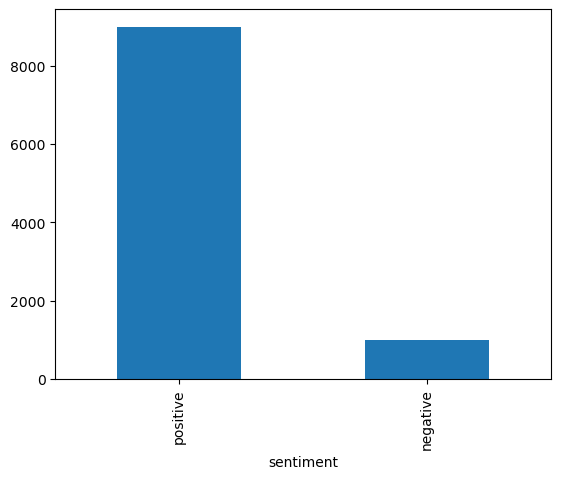

In [5]:
# make a barplot to how data is distrubuted
df_reviews_imb.value_counts('sentiment').plot(kind='bar')

## Balancing data with .sample()

In [6]:
len_negative = len(df_reviews_imb[df_reviews_imb['sentiment'] == 'negative'])

In [7]:
len_negative

1000

In [8]:
df_reviews_positive = df_reviews_imb[df_reviews_imb['sentiment'] == 'positive'].sample(n=len_negative)

In [9]:
df_reviews_negative = df_reviews_imb[df_reviews_imb['sentiment'] == 'negative']

In [10]:
df_reviews_bal = pd.concat([df_reviews_positive, df_reviews_negative])

In [11]:
df_reviews_bal.reset_index(drop = True, inplace = True)

In [12]:
df_reviews_bal

,review,sentiment
0,It was such a treat when this show was on beca...,positive
1,I love this movie and never get tired of watch...,positive
2,"This deceptively laid-back, low-key, casually ...",positive
3,I have seen 'The Sea Within' today and I loved...,positive
4,I would consider myself a fan of Dean Koontz; ...,positive
...,...,...
1995,Stranded in Space (1972) MST3K version - a ver...,negative
1996,"I happened to catch this supposed ""horror"" fli...",negative
1997,waste of 1h45 this nasty little film is one to...,negative
1998,Warning: This could spoil your movie. Watch it...,negative


## Balancing data with RandomUnderSampler

In [13]:
# !pip install imblearn
from imblearn.under_sampling import RandomUnderSampler
# for over sample
# from imblearn.over_sampling import RandomOverSampler

rus = RandomUnderSampler(random_state = 0)

In [14]:
df_review_bal, df_review_bal['sentiment'] = rus.fit_resample(
    df_reviews_imb[['review']], df_reviews_imb['sentiment'])

In [15]:
df_review_bal.value_counts('sentiment')

sentiment
negative    1000
positive    1000
Name: count, dtype: int64

# Splitting data into train and test

In [16]:
# import train_split
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_review_bal, test_size = 0.33,
                               random_state = 42)

In [17]:
# create train and test dataframes
test

,review,sentiment
11301,Refreshing `lost' gem! Featuring effective dia...,positive
681,Never saw the original movie in the series...I...,negative
7513,"Once upon a time, in Sweden, there was a poor ...",positive
1821,"At the beginning of the film, you might double...",negative
549,Another Spanish movie about the 1936 Civil War...,positive
...,...,...
207,"I have seen most, if not all of the Laurel & H...",negative
7616,D.W. Griffith could have made any film he want...,positive
13483,"Cardiff, Wales. A bunch of 5 mates are deeply ...",positive
1051,I rented this movie with my friend for a good ...,negative


In [18]:
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

In [19]:
train_x
train_y.value_counts()

sentiment
negative    675
positive    665
Name: count, dtype: int64

# Text Representation (Bag of Words)

## Count Vectorizer

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

In [21]:
text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]

df = pd.DataFrame({'review': ['review1', 'review2'],
                  'text': text})

cv = CountVectorizer(stop_words='english')
cv_matrix = cv.fit_transform(df['text'])

In [22]:
df_dtm = pd.DataFrame(cv_matrix.toarray(), index=df['review'].values,
                     columns=cv.get_feature_names_out()) # document term matrix

In [23]:
df_dtm

,code,hate,java,love,python,writing
review1,2,0,0,2,2,1
review2,2,2,2,0,0,1


## Tfidf

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]

df = pd.DataFrame({'review': ['review1', 'review2'],
                  'text': text})
tfidf = TfidfVectorizer(stop_words='english', norm=None)
tfidf_matrix = tfidf.fit_transform(df['text'])

In [25]:
pd.DataFrame(tfidf_matrix.toarray(),index=df['review'].values,
                     columns=tfidf.get_feature_names_out())

,code,hate,java,love,python,writing
review1,2.0,0.00000,0.00000,2.81093,2.81093,1.0
review2,2.0,2.81093,2.81093,0.00000,0.00000,1.0


# Turning our text data into numerical vectors

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
train_x_vector = tfidf.fit_transform(train_x)

In [27]:
test_x_vector = tfidf.transform(test_x)

In [28]:
test_x_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 53486 stored elements and shape (660, 20625)>

In [29]:
train_x_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 118834 stored elements and shape (1340, 20625)>

In [30]:
pd.DataFrame.sparse.from_spmatrix(train_x_vector,index=train_x.index,
                     columns=tfidf.get_feature_names_out())

,00,000,007,01pm,02,04,08,10,100,1000,...,zooming,zooms,zues,zzzzzzzzzzzzzzzzzz,æon,élan,émigré,ísnt,ïn,ünfaithful
144,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1839,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16588,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
742,0,0,0,0,0,0,0,0.042791,0,0,...,0,0,0,0,0,0,0,0,0,0
9464,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10644,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16133,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1739,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2443,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Model Selection

## Support Vector Machine (SVM)

In [31]:
from sklearn.svm import SVC

svc = SVC(kernel = 'linear')
svc.fit(train_x_vector, train_y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [32]:
svc.predict(tfidf.transform(['A good movie']))

array(['positive'], dtype=object)

In [33]:
svc.predict(tfidf.transform(['I did not like the movie']))

array(['negative'], dtype=object)

## Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier()
dec_tree.fit(train_x_vector, train_y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Naive Bayes

In [35]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(train_x_vector.toarray(), train_y)

,priors,None
,var_smoothing,1e-09


## Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(train_x_vector, train_y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Model Evaluation

## Confusion Matrix

In [37]:
# calculate confusion matrix of svc
from sklearn.metrics import confusion_matrix

confusion_matrix(test_y, 
                 svc.predict(test_x_vector), 
                 labels=['positive', 'negative'])

array([[290,  45],
       [ 60, 265]])

In [38]:
# calculate confusion matrix of decision tree, naive bayes, logistic regression 

## Mean Accuracy

In [39]:
# calculate accuracy of all models
print(svc.score(test_x_vector, test_y))
print(dec_tree.score(test_x_vector, test_y))
print(gnb.score(test_x_vector.toarray(), test_y))
print(log_reg.score(test_x_vector, test_y))
# model.score(test_x_vector, test_y)



0.8409090909090909
0.6545454545454545
0.6348484848484849
0.8303030303030303


## F1 Score

In [40]:
from sklearn.metrics import f1_score

f1_score(test_y, svc.predict(test_x_vector),
        labels=['positive', 'negative'],
        average=None)

array([0.84671533, 0.83464567])

## Classification report

In [41]:
from sklearn.metrics import classification_report

print(classification_report(test_y,
                     svc.predict(test_x_vector), 
                     labels=['positive', 'negative']))

              precision    recall  f1-score   support

    positive       0.83      0.87      0.85       335
    negative       0.85      0.82      0.83       325

    accuracy                           0.84       660
   macro avg       0.84      0.84      0.84       660
weighted avg       0.84      0.84      0.84       660



# Tuning the Model

## GridSearchCV

In [42]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': [1,4,8,16,32], 'kernel': ['linear', 'rbf']}
svc = SVC()
svc_grid = GridSearchCV(svc, parameters, cv=5)
svc_grid.fit(train_x_vector, train_y)

,estimator,SVC()
,param_grid,"{'C': [1, 4, ...], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [43]:
svc_grid.best_params_

{'C': 1, 'kernel': 'linear'}